<a href="https://colab.research.google.com/github/ThayseBachmeyer/ProcessamentoSinaisI/blob/main/Aula%2003/C%C3%B3digos/aula0409.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Código utilizado na questão 1

In [ ]:
# n°1

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


num = np.array([1,0,0.49,0,0,0,0.2401,0,-0.0576,0,-0.0282,0,-0.0138])
den = np.array([1])

freq, fase = signal.freqz(num, den, worN=512)
freq_norm = freq/(2*np.pi)

zero, polo, ganho = signal.tf2zpk(num, den)
magnitude_db = 20 * np.log10(np.maximum(np.abs(fase), 1e-10))

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

axs[0].plot(freq_norm, magnitude_db, 'b')
axs[0].set_title('Resposta em Frequência do Sistema')
axs[0].set_ylabel('Magnitude (dB)')
axs[0].set_xlabel('Frequência Normalizada')
axs[0].grid(True)

faserad = np.angle(fase)
axs[1].plot(freq_norm, faserad, 'g')
axs[1].set_ylabel('Fase (radianos)')
axs[1].set_xlabel('ω / π')
axs[1].grid(True)

theta = np.linspace(0, 2*np.pi, 512)
axs[2].plot(np.cos(theta), np.sin(theta), 'k--', label='Círculo Unitário')

plt.scatter(np.real(zero), np.imag(zero), s=50, marker='o', facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(polo), np.imag(polo), s=50, marker='x', color='r', label='Polos')

axs[2].set_xlim(-1.3, 1.3)
axs[2].set_ylim(-1.3, 1.3)
axs[2].set_title('Diagrama de Polos e Zeros')
axs[2].set_xlabel('Eixo Real')
axs[2].set_ylabel('Eixo Imaginário')
axs[2].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axs[2].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axs[2].set_aspect('equal')
axs[2].legend(loc='upper right')
axs[2].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Código utilizado na questão 2


In [ ]:
# n°2

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

num = np.array([1,0,0.49,0,0,0,0.2401,0,-0.0576,0,-0.0282,0,-0.0138])
den = np.array([1])

handel = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Aula%2003/Dados/handel.wav"
nome_handel = "handel.wav"

!wget -q -O {nome_handel} {handel}

fs, x = wavfile.read(nome_handel)
if len(x.shape) > 1:
    x = x[:, 0]

x = x.astype(np.float64)
x = x / np.max(np.abs(x))
y = signal.lfilter(num, den, x)
y = y / np.max(np.abs(y))

N = len(x)
X_fft = np.fft.rfft(x)
Y_fft = np.fft.rfft(y)

freqs = np.fft.rfftfreq(N, d=1/fs)
w, H = sig.freqz(num, den, worN=4096)
freqs_H = w * fs / (2 * np.pi)

Y_mag_db = 20 * np.log10(np.abs(Y_fft) + 1e-10)

tempo = np.arange(N) / fs

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

axs[0].plot(tempo, y)
axs[0].set_title('Sinais no Domínio do Tempo')
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)


axs[1].plot(freqs, Y_mag_db)
axs[1].set_title('Espectro de Frequência (Magnitude)')
axs[1].set_xlabel('Frequência (Hz)')
axs[1].set_ylabel('Magnitude (dB)')
axs[1].set_xlim([0, fs/2])
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Código utilizado na questão 3

In [ ]:
#n° 3

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

num = np.array([1,0,0.49,0,0,0,0.2401,0,-0.0576,0,-0.0282,0,-0.0138])
den = np.array([1])

handel = "https://github.com/ThayseBachmeyer/ProcessamentoSinaisI/raw/refs/heads/main/Aula%2003/Dados/handel.wav"
nome_handel = "handel.wav"

!wget -q -O {nome_handel} {handel}

fs, x = wavfile.read(nome_handel)
if len(x.shape) > 1:
    x = x[:, 0]

x = x / np.max(np.abs(x))
y = signal.lfilter(num, den, x)
y = y / np.max(np.abs(y))

num_inv = den
den_inv = num

x_recuperado = signal.lfilter(num_inv, den_inv, y)
x_norm = x / np.max(np.abs(x))
x_rec_norm = x_recuperado / np.max(np.abs(x_recuperado))

w_inv, h_freq_inv = signal.freqz(num_inv, den_inv, worN=8000)
zeros_inv, polos_inv, _ = signal.tf2zpk(num_inv, den_inv)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
magnitude_inv_db = 20 * np.log10(np.maximum(np.abs(h_freq_inv), 1e-10))
plt.plot(w_inv / np.pi, magnitude_inv_db, 'b')
plt.title('Resposta em Frequência (Filtro Inverso)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequência')
plt.grid(True)

plt.subplot(1, 2, 2)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Círculo Unitário')
plt.scatter(np.real(zeros_inv), np.imag(zeros_inv), s=60, facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(polos_inv), np.imag(polos_inv), s=60, marker='x', color='r', label='Polos')
plt.title('Polos e Zeros (Filtro Inverso)')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.axis('equal')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

Zeros de H(z) (viram polos do filtro inverso):
   -0.6197+0.4818j   |z| = 0.7850
   -0.6197-0.4818j   |z| = 0.7850
   -0.6679+0.0000j   |z| = 0.6679
   -0.0000+0.9336j   |z| = 0.9336
   -0.0000-0.9336j   |z| = 0.9336
   0.6197+0.4818j   |z| = 0.7850
   0.6197-0.4818j   |z| = 0.7850
   0.6679+0.0000j   |z| = 0.6679
   -0.2467+0.4949j   |z| = 0.5530
   -0.2467-0.4949j   |z| = 0.5530
   0.2467+0.4949j   |z| = 0.5530
   0.2467-0.4949j   |z| = 0.5530
>> H(z) é de fase mínima: o filtro inverso 1/H(z) é ESTÁVEL e CAUSAL.



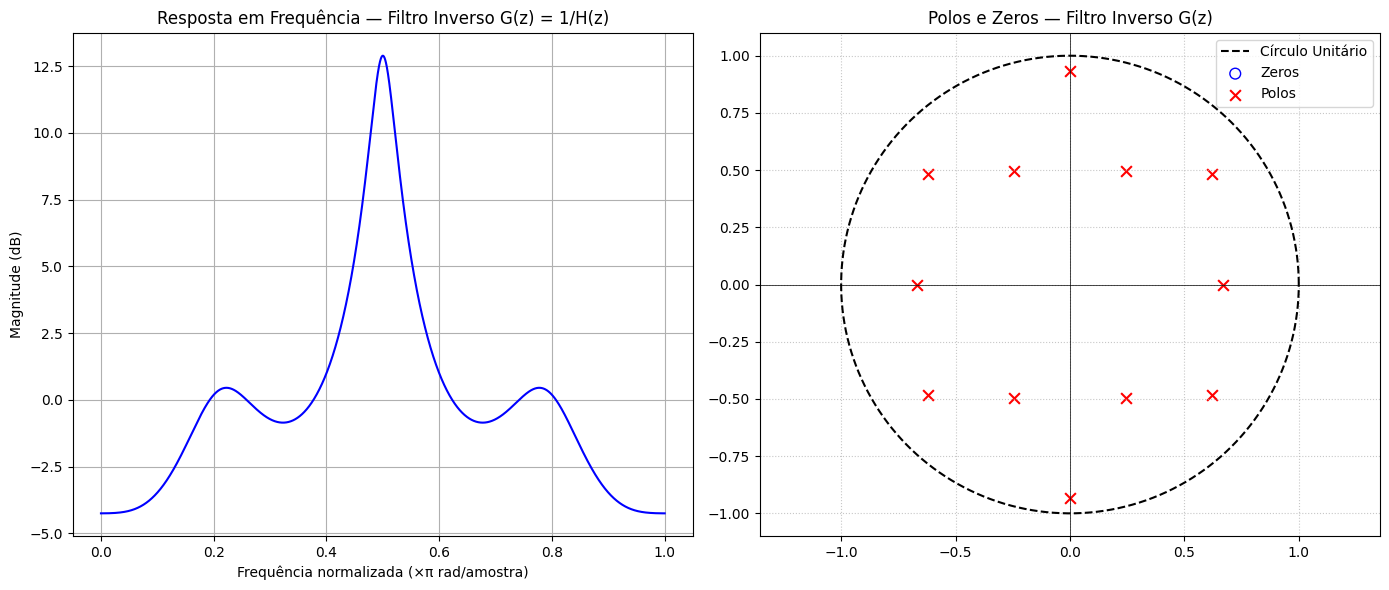

Avaliação da recuperação:
  MSE                 = 5.750e-33
  Correlação (x, x̂)   = 1.000000
  SNR de recuperação  = 310.20 dB


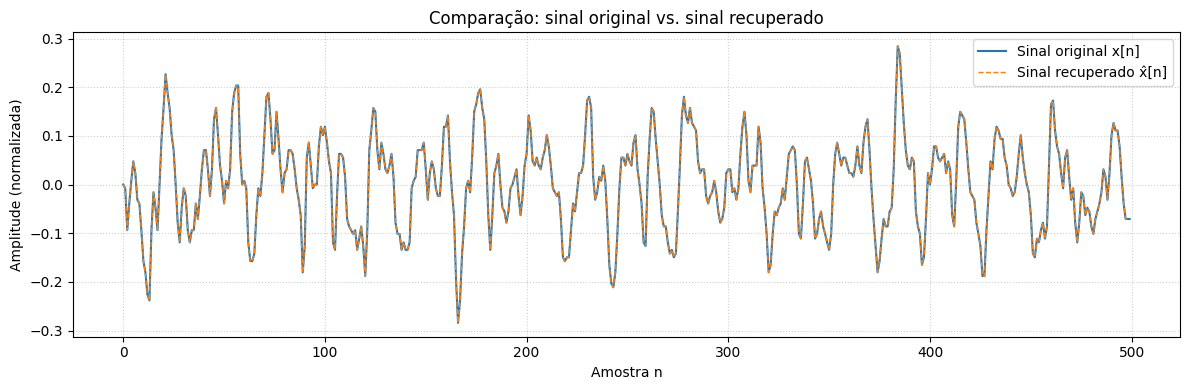

In [2]:
#teste 2 COD 3


import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

# ---------------------------------------------------------------
# 1. Filtro que degradou o sinal (dado no enunciado)
# ---------------------------------------------------------------
num = np.array([1, 0, 0.49, 0, 0, 0, 0.2401, 0, -0.0576, 0, -0.0282, 0, -0.0138])
den = np.array([1])

# ---------------------------------------------------------------
# 2. Carrega o áudio e aplica o filtro de degradação (canal)
# ---------------------------------------------------------------
import os
os.system(f"wget -q -O {nome_handel} {handel}")

fs, x = wavfile.read(nome_handel)
if len(x.shape) > 1:
    x = x[:, 0]
x = x.astype(float)
x = x / np.max(np.abs(x))

y = signal.lfilter(num, den, x)
y = y / np.max(np.abs(y))

# ---------------------------------------------------------------
# 3. Verifica se o filtro inverso é estável/causal (fase mínima)
# ---------------------------------------------------------------
zeros_H, polos_H, _ = signal.tf2zpk(num, den)
print("Zeros de H(z) (viram polos do filtro inverso):")
for z in zeros_H:
    print(f"   {z:.4f}   |z| = {abs(z):.4f}")

if np.all(np.abs(zeros_H) < 1):
    print(">> H(z) é de fase mínima: o filtro inverso 1/H(z) é ESTÁVEL e CAUSAL.\n")
else:
    print(">> H(z) NÃO é de fase mínima: o filtro inverso seria instável/não causal!\n")

# ---------------------------------------------------------------
# 4. Filtro de recuperação: G(z) = 1/H(z)
# ---------------------------------------------------------------
num_inv = den          # = [1]
den_inv = num          # coeficientes do filtro original

x_recuperado = signal.lfilter(num_inv, den_inv, y)
x_recuperado = x_recuperado / np.max(np.abs(x_recuperado))

# ---------------------------------------------------------------
# 5. Resposta em frequência e diagrama de polos/zeros do filtro inverso
# ---------------------------------------------------------------
w_inv, h_freq_inv = signal.freqz(num_inv, den_inv, worN=8000)
zeros_inv, polos_inv, _ = signal.tf2zpk(num_inv, den_inv)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
magnitude_inv_db = 20 * np.log10(np.maximum(np.abs(h_freq_inv), 1e-10))
plt.plot(w_inv / np.pi, magnitude_inv_db, 'b')
plt.title('Resposta em Frequência — Filtro Inverso G(z) = 1/H(z)')
plt.ylabel('Magnitude (dB)')
plt.xlabel('Frequência normalizada (×π rad/amostra)')
plt.grid(True)

plt.subplot(1, 2, 2)
theta = np.linspace(0, 2 * np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), 'k--', label='Círculo Unitário')
plt.scatter(np.real(zeros_inv), np.imag(zeros_inv), s=60, facecolors='none',
            edgecolors='b', label='Zeros')
plt.scatter(np.real(polos_inv), np.imag(polos_inv), s=60, marker='x',
            color='r', label='Polos')
plt.title('Polos e Zeros — Filtro Inverso G(z)')
plt.axhline(0, color='black', lw=0.5)
plt.axvline(0, color='black', lw=0.5)
plt.axis('equal')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig('resposta_freq_polos_zeros.png', dpi=150)
plt.show()

# ---------------------------------------------------------------
# 6. Avaliação quantitativa: x_recuperado vs x original
# ---------------------------------------------------------------
transiente = 50  # descarta amostras iniciais (transiente da resposta IIR)
x_ref = x[transiente:]
x_rec_ref = x_recuperado[transiente:len(x_ref) + transiente]

erro = x_ref - x_rec_ref
mse = np.mean(erro ** 2)
correlacao = np.corrcoef(x_ref, x_rec_ref)[0, 1]
snr_db = 10 * np.log10(np.sum(x_ref ** 2) / np.sum(erro ** 2))

print("Avaliação da recuperação:")
print(f"  MSE                 = {mse:.3e}")
print(f"  Correlação (x, x̂)   = {correlacao:.6f}")
print(f"  SNR de recuperação  = {snr_db:.2f} dB")

# ---------------------------------------------------------------
# 7. Comparação visual: sinal original x recuperado
# ---------------------------------------------------------------
n_plot = 500
plt.figure(figsize=(12, 4))
plt.plot(x[:n_plot], label='Sinal original x[n]', linewidth=1.5)
plt.plot(x_recuperado[:n_plot], '--', label='Sinal recuperado x̂[n]', linewidth=1)
plt.title('Comparação: sinal original vs. sinal recuperado')
plt.xlabel('Amostra n')
plt.ylabel('Amplitude (normalizada)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('comparacao_sinais.png', dpi=150)
plt.show()

wavfile.write('handel_recuperado.wav', fs, (x_recuperado * 32767).astype(np.int16))



## Código utilizado na questão 4

In [ ]:
#n° 4

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

def coeficientes_H(a, L):
    """
    Coeficientes do numerador (b) e do denominador (a_den) de
    H(z) = (1 - z^-L) / (1 - a*z^-L), na forma esperada por
    scipy.signal (potências crescentes de z^-1).
    """
    b = np.zeros(L + 1)
    b[0] = 1.0
    b[-1] = -1.0

    a_den = np.zeros(L + 1)
    a_den[0] = 1.0
    a_den[-1] = -a

    return b, a_den


def plota_polos_zeros(ax, zeros, polos, titulo):
    """Desenha o diagrama de polos e zeros no eixo `ax`."""
    theta = np.linspace(0, 2 * np.pi, 512)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=1)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

    ax.plot(np.real(zeros), np.imag(zeros), 'o', markersize=9,
            markerfacecolor='none', markeredgecolor='tab:blue', label='zeros')
    ax.plot(np.real(polos), np.imag(polos), 'x', markersize=9,
            markeredgecolor='tab:red', label='polos')

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel('Re(z)')
    ax.set_ylabel('Im(z)')
    ax.grid(alpha=0.3)


valores_a = [0.7, 0.9]
valores_L = [1, 4, 10]

for a in valores_a:
    for L in valores_L:
        b, a_den = coeficientes_H(a, L)


        zeros, polos, ganho = sig.tf2zpk(b, a_den)

        w, H = sig.freqz(b, a_den, worN=4096)

        fig, eixos = plt.subplots(1, 3, figsize=(15, 4))

        plota_polos_zeros(eixos[0], zeros, polos, f'Polos e zeros — a={a}, L={L}')
        eixos[0].legend(loc='upper right', fontsize=8)

        eixos[1].plot(w / np.pi, 20 * np.log10(np.abs(H) + 1e-12))
        eixos[1].set_title(f'Magnitude |H(e^jw)| — a={a}, L={L}', fontsize=10)
        eixos[1].set_xlabel('ω / π')
        eixos[1].set_ylabel('Magnitude (dB)')
        eixos[1].grid(alpha=0.3)

        eixos[2].plot(w / np.pi, np.unwrap(np.angle(H)))
        eixos[2].set_title(f'Fase de H(e^jw) — a={a}, L={L}', fontsize=10)
        eixos[2].set_xlabel('ω / π')
        eixos[2].set_ylabel('Fase (rad)')
        eixos[2].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

## Código utilizado na questão 5

In [ ]:
#n° 5

import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
